In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from Noise_functions import *
from PC_functions import *
from DCN_functions import *
from IO_functions import *
from Noise_PC_Synapses_functions import *
from PC_DCN_Synapses_functions import *
from DCN_IO_Synapses_functions import *
from IO_PC_Synapses_functions import *
from Other_synapses import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from Input_func import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Frozen_data = sio.loadmat('Data/'+datetime.datetime.now().strftime("%m-%d")+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synaps = Read_Input(Frozen_data)
###################################################################
######################## Initial Parameters #######################
###################################################################
dt = Params.dt
dt_rec = Params.dt_rec
width = Params.width
tau_noise = Params.tau_noise
exp_run = Params.exp_run
N_Noise = Params.N_Noise
N_Cells_PC = Params.N_Cells_PC
N_Cells_DCN = Params.N_Cells_DCN
N_Cells_IO = Params.N_Cells_IO
N_Copy = Params.N_Copy
N_Copy_order = Params.N_Copy_order
###################################################################
########################## Cell Values ############################
###################################################################
Noise_I = Noise_frozen.Noise_I
I_recorded = Noise_frozen.I_recorded
period = Noise_frozen.period
PC_Values = Values.PC_Values
DCN_Values = Values.DCN_Values
IO_Values = Values.IO_Values
IO_thresh = Values.IO_thresh
eqs_IO_syn = Values.eqs_IO_syn
rate_meas = Values.rate_meas
rate_meas_out = Values.rate_meas_out
tau_presyn = Values.tau_presyn
tau_thresh_M = 10*ms# Values.tau_thresh_M
sine_amplitude_presyn = Values.sine_amplitude_presyn
sine_frequency_presyn = Values.sine_frequency_presyn
eqs_syn_bcm_s_n_pc = Values.eqs_syn_bcm_s_n_pc
eqs_syn_IO_PC_pre = Values.eqs_syn_IO_PC_pre
###################################################################
###################### Synapses Values ############################
###################################################################
IO_Copy_Synapse_Targets = Synaps.IO_Copy_Synapse_Targets
Noise_PC_Synapse_Sources = Synaps.Noise_PC_Synapse_Sources
Noise_PC_Synapse_Targets = Synaps.Noise_PC_Synapse_Targets 
Noise_PC_Synapse_Weights = Synaps.Noise_PC_Synapse_Weights
PC_DCN_Synapse_Sources = Synaps.PC_DCN_Synapse_Sources
PC_DCN_Synapse_Targets = Synaps.PC_DCN_Synapse_Targets
DCN_IO_Synapse_Sources = Synaps.DCN_IO_Synapse_Sources 
DCN_IO_Synapse_Targets = Synaps.DCN_IO_Synapse_Targets 
IO_PC_Synapse_Sources = Synaps.IO_PC_Synapse_Sources
IO_PC_Synapse_Targets = Synaps.IO_PC_Synapse_Targets


def presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec):
    eqs_presyn = '''
            rho_presyn = ampli*noise_in: Hz
            noise_in : 1
            ampli : Hz
            '''
    Input_presyn = NeuronGroup(N_Noise, eqs_presyn, threshold='True', method='euler', dt=dt)
    Input_presyn_statemon = StateMonitor(Input_presyn, variables=['rho_presyn'], record=True, dt=dt_rec)
    ampli = rand_params(30,Hz,N_Noise,(5/N_Noise))
    for ii in range(0, N_Noise, 1):
        Input_presyn.ampli[ii] = ampli[ii]
    return Input_presyn, Input_presyn_statemon
###################################################################
###################################################################
############################## CELLS ##############################
###################################################################
###################################################################
############################## NOISE ##############################
###################################################################
Noise, Noise_statemon, Noise_extended, Noise_extended_statemon = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL ##########################
###################################################################
PC, PC_Statemon, PC_Spikemon, PC_rate = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################## DEEP CEREBELLAR NUCLEI CELLS ###################
###################################################################
DCN, DCN_Statemon, DCN_Spikemon, DCN_rate = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO ##################################
###################################################################
IO, IO_Statemon, IO_Spikemon, IO_rate = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
###################################################################
############################# PF ##################################
###################################################################
Input_presyn, Input_presyn_statemon = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate ################################
###################################################################
syn = rate_meas_func(rate_meas,PC,dt)
syn.connect(j='i')  
syn.subtract.delay = rate_meas_out  # delay the subtraction
###################################################################
############################# Copy ################################
###################################################################
conn_N_PC, mon_N_PC = conn_N_PC_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)
###################################################################
###################################################################
########################## SYNAPSES ###############################
###################################################################
###################################################################
########################## PC DCN Synapse #########################
###################################################################
PC_DCN_Synapse = PC_DCN_syn(PC,DCN,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
########################## DCN IO Synapse #########################
###################################################################
DCN_IO_Synapse = DCN_IO_syn(DCN,IO,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
########################## IO ConnPC Synapse ######################
###################################################################
S_IO_N = Synapses(IO, conn_N_PC, method='euler',dt=dt)  # where f is 
S_IO_N.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
########################### IO PC Synapse #########################
###################################################################
IO_PC_Synapse = Synapses(IO, PC, on_pre =eqs_syn_IO_PC_pre, delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
######################### ConnPC PC Synapse #######################
###################################################################
S_N_PC = Synapses(conn_N_PC,PC, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
########################## ConnPC Noise Synapse ###################
###################################################################
S_PC_N = Synapses(conn_N_PC,Noise_extended, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
############################# Copy rate ###########################
###################################################################
copy_rate = Synapses(Input_presyn, conn_N_PC, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
############################ Copy Noise ###########################
###################################################################
copy_noise = Synapses(Noise_extended, conn_N_PC, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise.weight = Noise_PC_Synapse_Weights
###################################################################
########################## PC Rate Synapse ########################
###################################################################
S_PC_rate = Synapses(PC,conn_N_PC, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)

presyn_Noise_syn = Synapses(Noise_extended, Input_presyn, 'noise_in_post = I_pre/nA : 1 (summed)',method='euler',dt=dt)  # where f is 
presyn_Noise_syn.connect(j = 'i')

ld: warning: -pie being ignored. It is only used when linking a main executable
ld: unsupported tapi file type '!tapi-tbd' in YAML file '/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/lib/libSystem.tbd' for architecture x86_64
clang-10: error: linker command failed with exit code 1 (use -v to see invocation)
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-apple-darwin13.4.0-clang++' failed with exit status 1 (LinkError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


CPU times: user 2.38 s, sys: 572 ms, total: 2.95 s
Wall time: 5.28 s


In [2]:
###################################################################
###################################################################
############################## CELLS COUPLED ######################
###################################################################
###################################################################
############################## NOISE COUPLED ######################
###################################################################
Noise_Coupled, Noise_statemon_Coupled, Noise_extended_Coupled, Noise_extended_statemon_Coupled = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL COUPLED ##################
###################################################################
PC_Coupled, PC_Statemon_Coupled, PC_Spikemon_Coupled, PC_rate_Coupled = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################ DEEP CEREBELLAR NUCLEI CELLS COUPLED #############
###################################################################
DCN_Coupled, DCN_Statemon_Coupled, DCN_Spikemon_Coupled, DCN_rate_Coupled = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO COUPLED ##########################
###################################################################
IO_Coupled, IO_Statemon_Coupled, IO_Spikemon_Coupled, IO_rate_Coupled = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
IO_synapse_Coupled = IO_coup_syn(IO_Coupled,eqs_IO_syn) # create synaptic equations and apply full synaptic strength for second network
IO_synapse_Coupled.connect() # connect second network
###################################################################
############################# PF COUPLED ##########################
###################################################################
Input_presyn_Coupled, Input_presyn_statemon_Coupled = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate COUPLED ########################
###################################################################
syn_Coupled = rate_meas_func(rate_meas,PC_Coupled,dt)
syn_Coupled.connect(j='i')  
syn_Coupled.subtract.delay = rate_meas_out  # delay the subtraction 
###################################################################
############################# Copy COUPLED ########################
###################################################################
conn_N_PC_Coupled, mon_N_PC_Coupled = conn_N_PC_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)
###################################################################
###################################################################
####################### SYNAPSES COUPLED ##########################
###################################################################
###################################################################
########################## PC DCN Synapse #########################
###################################################################
PC_DCN_Synapse_Coupled = PC_DCN_syn(PC_Coupled,DCN_Coupled,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse_Coupled.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
#################### DCN IO Synapse COUPLED #######################
###################################################################
DCN_IO_Synapse_Coupled = DCN_IO_syn(DCN_Coupled,IO_Coupled,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse_Coupled.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
################# IO ConnPC Synapse COUPLED #######################
###################################################################
S_IO_N_Coupled = Synapses(IO_Coupled, conn_N_PC_Coupled, method='euler',dt=dt)  # where f is 
S_IO_N_Coupled.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
##################### IO PC Synapse COUPLED #######################
###################################################################
IO_PC_Synapse_Coupled = Synapses(IO_Coupled, PC_Coupled, on_pre =eqs_syn_IO_PC_pre, delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse_Coupled.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
################# ConnPC PC Synapse COUPLED #######################
###################################################################
S_N_PC_Coupled = Synapses(conn_N_PC_Coupled,PC_Coupled, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
############## ConnPC Noise Synapse COUPLED #######################
###################################################################
S_PC_N_Coupled = Synapses(conn_N_PC_Coupled,Noise_extended_Coupled, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
######################### Copy rate COUPLED #######################
###################################################################
copy_rate_Coupled = Synapses(Input_presyn_Coupled, conn_N_PC_Coupled, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
######################## Copy Noise COUPLED #######################
###################################################################
copy_noise_Coupled = Synapses(Noise_extended_Coupled, conn_N_PC_Coupled, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise_Coupled.weight = Noise_PC_Synapse_Weights
###################################################################
################### PC Rate Synapse COUPLED #######################
########################################################`###########
S_PC_rate_Coupled = Synapses(PC_Coupled,conn_N_PC_Coupled, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate_Coupled.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)

presyn_Noise_syn_Coupled = Synapses(Noise_extended_Coupled, Input_presyn_Coupled, 'noise_in_post = I_pre/nA : 1 (summed)',method='euler',dt=dt)  # where f is 
presyn_Noise_syn_Coupled.connect(j = 'i')

In [3]:
a_OU = 1.5
b_OU = .5
###################################################################
conn_N_PC.thresh_M = 200*Hz

IO.g_Ca_l =  0.375*mS/cm**2
IO.sigma_OU = 0.5*uA/cm**2
IO.I_OU = a_OU*uA/cm**2
IO.I0_OU = a_OU*uA/cm**2
###################################################################
conn_N_PC_Coupled.thresh_M = 200*Hz

IO_Coupled.g_Ca_l =  0.375*mS/cm**2
IO_Coupled.sigma_OU = 0.5*uA/cm**2
IO_Coupled.I_OU = a_OU*uA/cm**2
IO_Coupled.I0_OU = a_OU*uA/cm**2


###################################################################
########################### RUN ###################################
###################################################################
run(2*exp_run,report='text') # Report on the simulation

Starting simulation at t=0. s for a duration of 240. s
109.075 ms (0%) simulated in 10s, estimated 6h 6m 37s remaining.
219.45 ms (0%) simulated in 20s, estimated 6h 4m 16s remaining.
0.340375 s (0%) simulated in 30s, estimated 5h 52m 6s remaining.
0.4608 s (0%) simulated in 40s, estimated 5h 46m 36s remaining.
0.583275 s (0%) simulated in 50s, estimated 5h 42m 7s remaining.
0.702725 s (0%) simulated in 1m 0s, estimated 5h 40m 35s remaining.
0.831775 s (0%) simulated in 1m 10s, estimated 5h 35m 32s remaining.
0.955675 s (0%) simulated in 1m 20s, estimated 5h 33m 34s remaining.
1.095975 s (0%) simulated in 1m 30s, estimated 5h 27m 2s remaining.
1.2421 s (0%) simulated in 1m 40s, estimated 5h 20m 25s remaining.
1.3886 s (0%) simulated in 1m 50s, estimated 5h 15m 5s remaining.
1.534575 s (0%) simulated in 2m 0s, estimated 5h 10m 50s remaining.
1.682125 s (0%) simulated in 2m 10s, estimated 5h 7m 1s remaining.
1.8299 s (0%) simulated in 2m 20s, estimated 5h 3m 44s remaining.
1.960425 s (0%

16.632375 s (6%) simulated in 20m 0s, estimated 4h 28m 37s remaining.
16.7692 s (6%) simulated in 20m 10s, estimated 4h 28m 29s remaining.
16.9085 s (7%) simulated in 20m 20s, estimated 4h 28m 18s remaining.
17.0479 s (7%) simulated in 20m 30s, estimated 4h 28m 8s remaining.
17.191175 s (7%) simulated in 20m 40s, estimated 4h 27m 53s remaining.
17.330325 s (7%) simulated in 20m 50s, estimated 4h 27m 42s remaining.
17.46975 s (7%) simulated in 21m 0s, estimated 4h 27m 32s remaining.
17.610275 s (7%) simulated in 21m 10s, estimated 4h 27m 20s remaining.
17.751625 s (7%) simulated in 21m 20s, estimated 4h 27m 7s remaining.
17.8992 s (7%) simulated in 21m 30s, estimated 4h 26m 49s remaining.
18.044875 s (7%) simulated in 21m 40s, estimated 4h 26m 32s remaining.
18.1909 s (7%) simulated in 21m 50s, estimated 4h 26m 15s remaining.
18.33765 s (7%) simulated in 22m 0s, estimated 4h 25m 58s remaining.
18.477675 s (7%) simulated in 22m 10s, estimated 4h 25m 47s remaining.
18.61725 s (7%) simulat

32.89045 s (13%) simulated in 39m 30s, estimated 4h 8m 46s remaining.
33.023725 s (13%) simulated in 39m 40s, estimated 4h 8m 39s remaining.
33.1543 s (13%) simulated in 39m 50s, estimated 4h 8m 33s remaining.
33.278625 s (13%) simulated in 40m 0s, estimated 4h 8m 31s remaining.
33.407925 s (13%) simulated in 40m 10s, estimated 4h 8m 25s remaining.
33.5243 s (13%) simulated in 40m 20s, estimated 4h 8m 27s remaining.
33.657875 s (14%) simulated in 40m 30s, estimated 4h 8m 19s remaining.
33.785275 s (14%) simulated in 40m 40s, estimated 4h 8m 15s remaining.
33.92425 s (14%) simulated in 40m 50s, estimated 4h 8m 5s remaining.
34.063775 s (14%) simulated in 41m 0s, estimated 4h 7m 54s remaining.
34.198775 s (14%) simulated in 41m 10s, estimated 4h 7m 46s remaining.
34.3309 s (14%) simulated in 41m 20s, estimated 4h 7m 39s remaining.
34.461625 s (14%) simulated in 41m 30s, estimated 4h 7m 33s remaining.
34.590025 s (14%) simulated in 41m 40s, estimated 4h 7m 28s remaining.
34.727625 s (14%)

48.39505 s (20%) simulated in 59m 0s, estimated 3h 53m 37s remaining.
48.5236 s (20%) simulated in 59m 10s, estimated 3h 53m 30s remaining.
48.6589 s (20%) simulated in 59m 20s, estimated 3h 53m 21s remaining.
48.796 s (20%) simulated in 59m 30s, estimated 3h 53m 11s remaining.
48.9306 s (20%) simulated in 59m 40s, estimated 3h 53m 1s remaining.
49.067825 s (20%) simulated in 59m 50s, estimated 3h 52m 51s remaining.
49.204075 s (20%) simulated in 1h 0m 0s, estimated 3h 52m 41s remaining.
49.3382 s (20%) simulated in 1h 0m 10s, estimated 3h 52m 32s remaining.
49.463775 s (20%) simulated in 1h 0m 20s, estimated 3h 52m 26s remaining.
49.592325 s (20%) simulated in 1h 0m 30s, estimated 3h 52m 19s remaining.
49.7237 s (20%) simulated in 1h 0m 40s, estimated 3h 52m 11s remaining.
49.85205 s (20%) simulated in 1h 0m 50s, estimated 3h 52m 4s remaining.
49.982575 s (20%) simulated in 1h 1m 0s, estimated 3h 51m 56s remaining.
50.1047 s (20%) simulated in 1h 1m 10s, estimated 3h 51m 51s remaining

62.755325 s (26%) simulated in 1h 17m 40s, estimated 3h 39m 23s remaining.
62.8835 s (26%) simulated in 1h 17m 50s, estimated 3h 39m 15s remaining.
63.0058 s (26%) simulated in 1h 18m 0s, estimated 3h 39m 9s remaining.
63.1305 s (26%) simulated in 1h 18m 10s, estimated 3h 39m 1s remaining.
63.25645 s (26%) simulated in 1h 18m 20s, estimated 3h 38m 54s remaining.
63.385625 s (26%) simulated in 1h 18m 30s, estimated 3h 38m 45s remaining.
63.5128 s (26%) simulated in 1h 18m 40s, estimated 3h 38m 37s remaining.
63.641975 s (26%) simulated in 1h 18m 50s, estimated 3h 38m 29s remaining.
63.7684 s (26%) simulated in 1h 19m 0s, estimated 3h 38m 21s remaining.
63.905575 s (26%) simulated in 1h 19m 10s, estimated 3h 38m 10s remaining.
64.04055 s (26%) simulated in 1h 19m 20s, estimated 3h 38m 0s remaining.
64.1698 s (26%) simulated in 1h 19m 30s, estimated 3h 37m 52s remaining.
64.305075 s (26%) simulated in 1h 19m 40s, estimated 3h 37m 42s remaining.
64.4408 s (26%) simulated in 1h 19m 50s, est

...

160.33825 s (66%) simulated in 3h 38m 37s, estimated 1h 48m 37s remaining.
160.485275 s (66%) simulated in 3h 38m 47s, estimated 1h 48m 24s remaining.
160.595875 s (66%) simulated in 3h 38m 57s, estimated 1h 48m 16s remaining.
160.744175 s (66%) simulated in 3h 39m 7s, estimated 1h 48m 3s remaining.
160.894325 s (67%) simulated in 3h 39m 17s, estimated 1h 47m 49s remaining.
161.041825 s (67%) simulated in 3h 39m 27s, estimated 1h 47m 36s remaining.
161.188425 s (67%) simulated in 3h 39m 37s, estimated 1h 47m 23s remaining.
161.331875 s (67%) simulated in 3h 39m 47s, estimated 1h 47m 11s remaining.
161.467775 s (67%) simulated in 3h 39m 57s, estimated 1h 46m 59s remaining.
161.6103 s (67%) simulated in 3h 40m 7s, estimated 1h 46m 47s remaining.
161.758425 s (67%) simulated in 3h 40m 17s, estimated 1h 46m 33s remaining.
161.904225 s (67%) simulated in 3h 40m 27s, estimated 1h 46m 21s remaining.
162.038375 s (67%) simulated in 3h 40m 37s, estimated 1h 46m 9s remaining.
162.18385 s (67%) s

176.450475 s (73%) simulated in 3h 56m 57s, estimated 1h 25m 21s remaining.
176.596175 s (73%) simulated in 3h 57m 7s, estimated 1h 25m 8s remaining.
176.742125 s (73%) simulated in 3h 57m 17s, estimated 1h 24m 56s remaining.
176.885825 s (73%) simulated in 3h 57m 27s, estimated 1h 24m 44s remaining.
177.0324 s (73%) simulated in 3h 57m 37s, estimated 1h 24m 31s remaining.
177.1756 s (73%) simulated in 3h 57m 47s, estimated 1h 24m 19s remaining.
177.3173 s (73%) simulated in 3h 57m 57s, estimated 1h 24m 7s remaining.
177.465275 s (73%) simulated in 3h 58m 7s, estimated 1h 23m 55s remaining.
177.610475 s (74%) simulated in 3h 58m 17s, estimated 1h 23m 42s remaining.
177.758725 s (74%) simulated in 3h 58m 28s, estimated 1h 23m 30s remaining.
177.90525 s (74%) simulated in 3h 58m 38s, estimated 1h 23m 17s remaining.
178.056025 s (74%) simulated in 3h 58m 48s, estimated 1h 23m 5s remaining.
178.20455 s (74%) simulated in 3h 58m 58s, estimated 1h 22m 52s remaining.
178.351675 s (74%) simula

192.978525 s (80%) simulated in 4h 15m 28s, estimated 1h 2m 15s remaining.
193.13375 s (80%) simulated in 4h 15m 38s, estimated 1h 2m 2s remaining.
193.289125 s (80%) simulated in 4h 15m 48s, estimated 1h 1m 49s remaining.
193.439275 s (80%) simulated in 4h 15m 58s, estimated 1h 1m 37s remaining.
193.59285 s (80%) simulated in 4h 16m 8s, estimated 1h 1m 24s remaining.
193.74 s (80%) simulated in 4h 16m 18s, estimated 1h 1m 12s remaining.
193.890775 s (80%) simulated in 4h 16m 28s, estimated 1h 0m 59s remaining.
194.039575 s (80%) simulated in 4h 16m 38s, estimated 1h 0m 47s remaining.
194.18595 s (80%) simulated in 4h 16m 48s, estimated 1h 0m 35s remaining.
194.330225 s (80%) simulated in 4h 16m 58s, estimated 1h 0m 23s remaining.
194.47675 s (81%) simulated in 4h 17m 8s, estimated 1h 0m 11s remaining.
194.62595 s (81%) simulated in 4h 17m 18s, estimated 59m 59s remaining.
194.77905 s (81%) simulated in 4h 17m 28s, estimated 59m 47s remaining.
194.9186 s (81%) simulated in 4h 17m 38s, 

210.84725 s (87%) simulated in 4h 34m 28s, estimated 37m 57s remaining.
211.006925 s (87%) simulated in 4h 34m 38s, estimated 37m 44s remaining.
211.16865 s (87%) simulated in 4h 34m 48s, estimated 37m 31s remaining.
211.33005 s (88%) simulated in 4h 34m 58s, estimated 37m 18s remaining.
211.4916 s (88%) simulated in 4h 35m 8s, estimated 37m 5s remaining.
211.65245 s (88%) simulated in 4h 35m 18s, estimated 36m 52s remaining.
211.81295 s (88%) simulated in 4h 35m 28s, estimated 36m 39s remaining.
211.972875 s (88%) simulated in 4h 35m 38s, estimated 36m 27s remaining.
212.13285 s (88%) simulated in 4h 35m 48s, estimated 36m 14s remaining.
212.29 s (88%) simulated in 4h 35m 58s, estimated 36m 1s remaining.
212.45005 s (88%) simulated in 4h 36m 8s, estimated 35m 49s remaining.
212.611325 s (88%) simulated in 4h 36m 18s, estimated 35m 36s remaining.
212.771475 s (88%) simulated in 4h 36m 28s, estimated 35m 23s remaining.
212.932825 s (88%) simulated in 4h 36m 38s, estimated 35m 10s remain

228.937525 s (95%) simulated in 4h 53m 28s, estimated 14m 11s remaining.
229.09865 s (95%) simulated in 4h 53m 38s, estimated 13m 58s remaining.
229.258175 s (95%) simulated in 4h 53m 48s, estimated 13m 46s remaining.
229.4175 s (95%) simulated in 4h 53m 58s, estimated 13m 34s remaining.
229.571175 s (95%) simulated in 4h 54m 8s, estimated 13m 22s remaining.
229.728025 s (95%) simulated in 4h 54m 18s, estimated 13m 10s remaining.
229.88525 s (95%) simulated in 4h 54m 28s, estimated 12m 57s remaining.
230.04255 s (95%) simulated in 4h 54m 38s, estimated 12m 45s remaining.
230.202075 s (95%) simulated in 4h 54m 48s, estimated 12m 33s remaining.
230.36125 s (95%) simulated in 4h 54m 58s, estimated 12m 21s remaining.
230.520275 s (96%) simulated in 4h 55m 8s, estimated 12m 8s remaining.
230.679575 s (96%) simulated in 4h 55m 18s, estimated 11m 56s remaining.
230.838325 s (96%) simulated in 4h 55m 28s, estimated 11m 44s remaining.
230.998425 s (96%) simulated in 4h 55m 38s, estimated 11m 31

In [4]:
%%time
from read_data import *
Create_output("_Learned_BCM",width,Noise_statemon,Noise_extended_statemon,PC_Statemon,PC_Spikemon, PC_rate,DCN_Statemon,DCN_Spikemon, DCN_rate,IO_Statemon,IO_Spikemon,IO_rate,mon_N_PC,Noise_statemon_Coupled,Noise_extended_statemon_Coupled,PC_Statemon_Coupled,PC_Spikemon_Coupled, PC_rate_Coupled,DCN_Statemon_Coupled,DCN_Spikemon_Coupled,DCN_rate_Coupled,IO_Statemon_Coupled,IO_Spikemon_Coupled,IO_rate_Coupled,mon_N_PC_Coupled)

Successfully created the directory /Users/eliasmateofernandezsantoro/Documents/Erasmus MC/Papers/CerbellarLoopPaper/CerebellarLoop/Code/2021/June/4 


WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)
 [py.warnings]
  return array(a, dtype, copy=False, order=order, subok=True)



21:54
CPU times: user 21min 14s, sys: 1min 55s, total: 23min 9s
Wall time: 1h 6min 8s


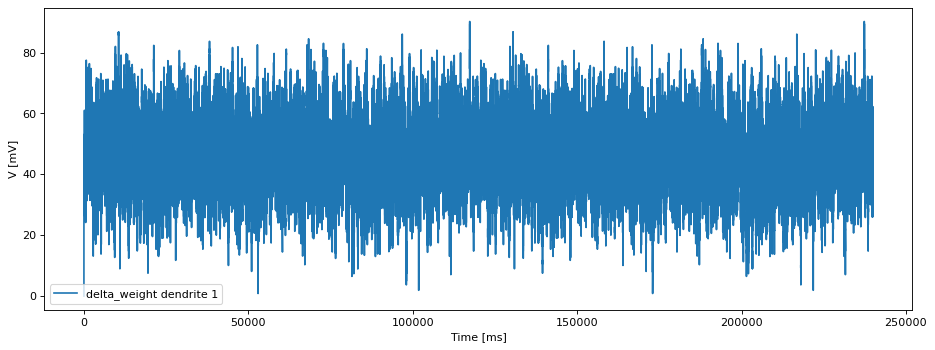

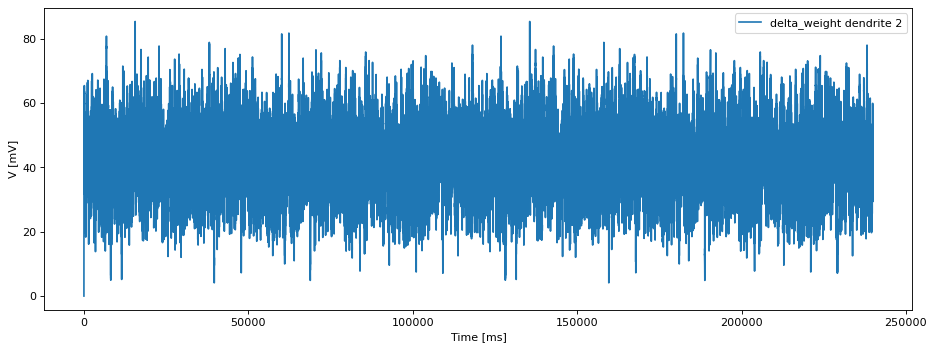

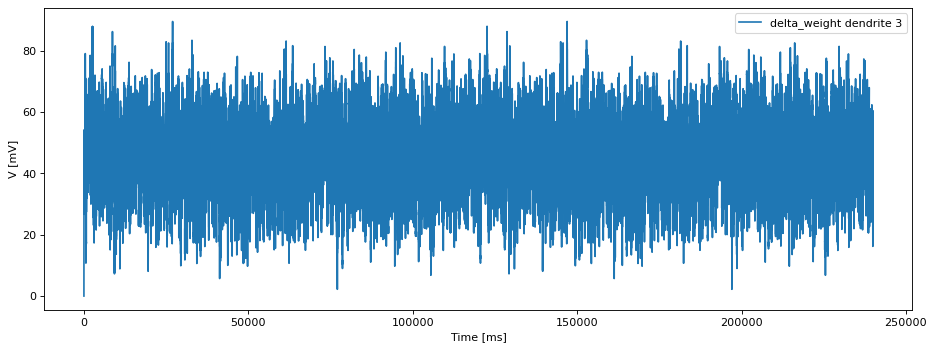

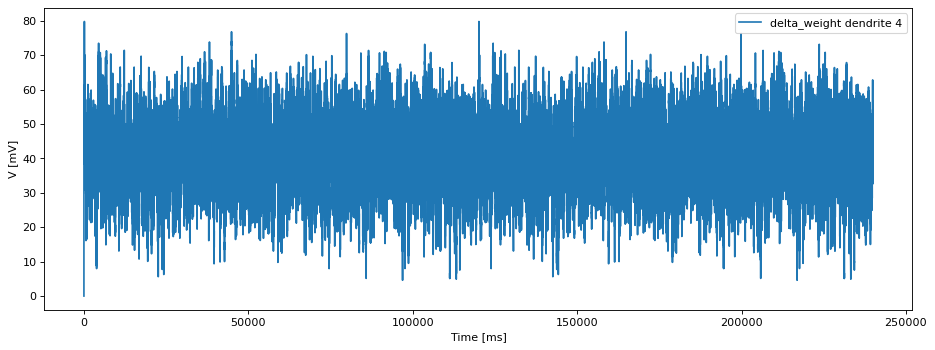

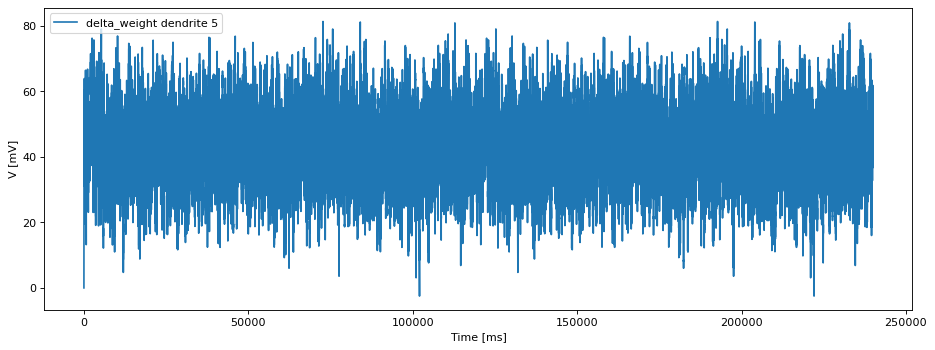

In [5]:
for ii in range(0,Params.N_Noise):
    plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    plot(Noise_extended_statemon.t/ms,Input_presyn_statemon.rho_presyn[ii],label="delta_weight dendrite "+str(ii+1))
    ylabel('V [mV]')
    xlabel('Time [ms]')
    legend()
    show()

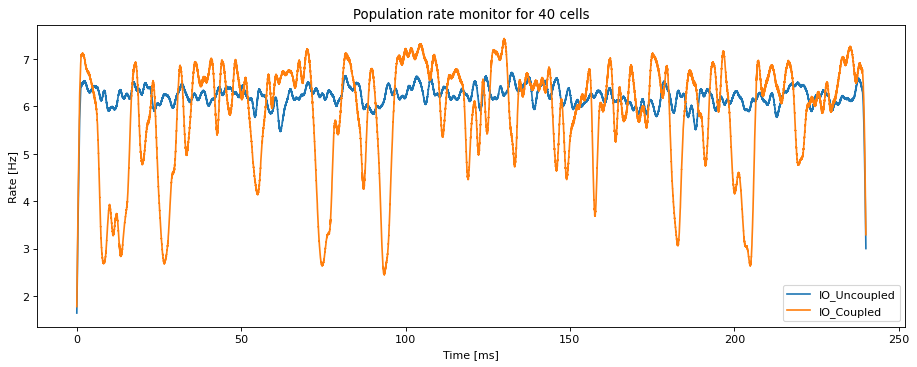

In [6]:
width = 500*ms
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(IO_rate.t, IO_rate.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Uncoupled')
plot(IO_rate_Coupled.t, IO_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

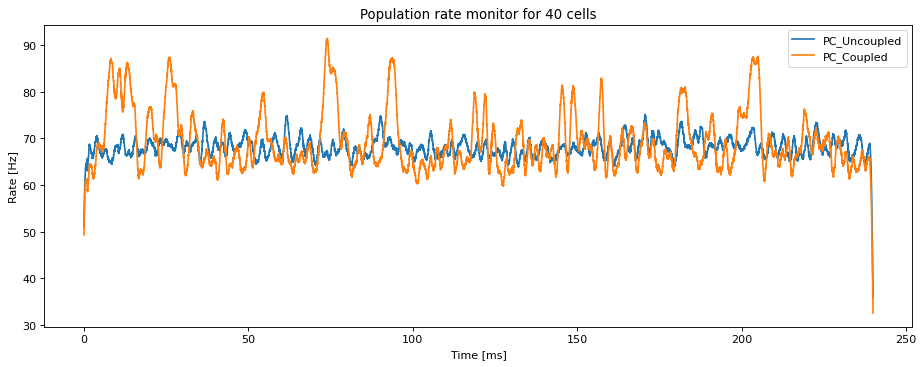

In [7]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_rate.t, PC_rate.smooth_rate(window='gaussian', width=width)/Hz, label='PC_Uncoupled')
plot(PC_rate_Coupled.t, PC_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='PC_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

In [ ]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(DCN_rate.t, DCN_rate.smooth_rate(window='gaussian', width=width)/Hz, label='DCN_Uncoupled')
plot(DCN_rate_Coupled.t, DCN_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='DCN_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

In [ ]:
%%time
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm = PC_Statemon[ii].v[:]
    for t in PC_Spikemon.t:
        i = int(t / dt_rec)
        vm[i] = 20*mV
    plot(PC_Statemon.t/ms,vm/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" PC cells (Uncoupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon.t/ms,IO_Statemon.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_IO)+" IO cells (Uncoupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm_Coupled = PC_Statemon_Coupled[ii].v[:]
    for t in PC_Spikemon_Coupled.t:
        i = int(t / dt_rec)
        vm_Coupled[i] = 20*mV
    plot(PC_Statemon_Coupled.t/ms,vm_Coupled/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" PC cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_IO):
    plot(IO_Statemon_Coupled.t/ms,IO_Statemon_Coupled.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_IO)+" cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

In [ ]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC*Params.N_Noise):
    plot(mon_N_PC.rho_PC[0],mon_N_PC.phi[ii])
ylabel('phi [Hz]')
xlabel('rho_PC [Hz]')
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC*Params.N_Noise):
    plot(mon_N_PC.t/ms,mon_N_PC.thresh_M[ii])
ylabel('thresh_M [Hz]')
xlabel('Time [ms]')
show()

In [ ]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,Params.N_Cells_PC*Params.N_Noise):
    plot(mon_N_PC.t/ms,mon_N_PC.thresh_M[ii],label=str(ii))
ylabel('thresh_M [Hz]')
xlabel('Time [ms]')
legend()
show()